# Vectorized crossover parameter search — MES on Tradovate (1m candles), single-symbol / single-strategy

Goal: pick **one** fast/slow crossover indicator pair and **one** parameter set to run
as MES's only strategy in `test_backtester_mes_tradovate.ipynb`. This notebook is the
research pipeline that earns that choice, per
`apps/backtester/OPTIMIZATION_RESEARCH_PLAN.md`.

**Pipeline** (each stage is its own cell(s) below):
1. **Shared harness**: real Tradovate/Tradeify cost model (researched, not
   placeholders — see below) + a scorecard function computing Sharpe/Sortino/Calmar/
   max-drawdown (daily-resampled, same convention `PerformanceAnalyzer` uses) and,
   critically, a **trade-level Sharpe lower bound** (`trade_sharpe_lb`) — this is the
   ranking metric, and it's what actually resolves "profitable but too few trades":
   see the methodology cell below for why.
2. **Four independent grid-search experiments**, same fast<long lengths grid, same
   scoring, different indicator pair: KAMA(fast)/SMA(slow), EMA(fast)/SMA(slow),
   HMA(fast)/SMA(slow), DEMA(fast)/SMA(slow). Each prints a sorted-best-to-worst
   table and a heatmap of the ranking metric across the parameter grid.
3. **Cross-experiment comparison**: one table, best combo per indicator family.
4. **Out-of-sample check**: the winner evaluated on a held-out final slice of data it
   never touched during the grid search (the cheapest possible overfitting guard —
   see `OPTIMIZATION_RESEARCH_PLAN.md` §5.1).
5. **Final pick**, with honest caveats about what this pipeline does and doesn't
   establish.

**Real costs used below (researched 2026-07-10, see `PROP_FIRM_PLAN.md`)**:
- MES tick size: 0.25 index points = $1.25/tick (CME contract spec).
- MES commission: Tradeify charges $1.82 round-turn -> $0.91/side (this cost model
  charges per fill, matching `TradovateSymbolConfigProvider.get_fee()`'s per-side
  billing in the event-driven engine).
- Slippage: 1 tick/side (`TradovateSymbolConfigProvider`'s general default).
- These are no longer frictionless placeholders like the previous version of this
  notebook used — every number below already has trading costs baked in.

**Data source: Databento, full history**: this notebook loads MES's full
available continuous-contract history from Databento (`GLBX.MDP3`, `MES.c.0` —
see `data_aggregator.databento_aggregator`) instead of the Mongo/Timescale IB
feed. That previous feed only actually had ~1 year of real MES data despite
nominal `DATE_FROM`/`DATE_TO` bounds spanning back to 2019 — a gap an earlier
version of this cell called out explicitly. This searches over MES's real
~7-year history (2019-05 onward), not an approximation of it.

**This pass: 1-minute bars, not 1-hour** — every experiment/section below now
runs on `UNIT_OF_TIME="minute"` instead of `"hour"`, specifically to look for
genuinely intraday holds (a few minutes to a few hours) rather than the
multi-day holds every winner so far has had. The same numeric length ranges
(`long_len_range`/`short_len_range`, KAMA rescan/smoothing ranges) are reused
unchanged from the hourly pass -- deliberately, so the same lookback *window
shapes* now apply to minutes instead of hours, and the actual resulting holding
periods (not a re-guessed range) are what tells us whether that lands in the
intended few-minutes-to-few-hours zone or needs further adjustment. Results
below aren't comparable to any hourly-bar run of this notebook -- different
granularity entirely, not just a parameter change.

**Deliberately out of scope for this pass** (see `OPTIMIZATION_RESEARCH_PLAN.md` for
why each is deferred, not forgotten):
- Re-tuning KAMA's own EMA fast/slow smoothing constants on top of the length grid
  (an earlier version of this notebook did this and found a modest improvement, but
  stacking a second grid search on the same ~1 year of data compounds overfitting
  risk for a gain that didn't survive this pass's out-of-sample check anyway).
- Breakout-style systems (Donchian, SuperTrend) — structurally not a two-line
  crossover, would need a new `Strategy` subclass in the event engine to use, not just
  a new indicator pair.
- Full walk-forward / CSCV overfitting-probability scoring, position sizing, and the
  Tradeify Monte-Carlo pass-probability simulator — all require either more data or
  more infrastructure than fits in this pass; tracked as `OPTIMIZATION_RESEARCH_PLAN.md`
  §2/§5.2-5.3/§7.2.


In [1]:
import itertools as it
import os
from pathlib import Path

import matplotlib.pyplot as plt
import multiprocess as mp
import numpy as np
import pandas as pd
import pandas_ta as ta
import seaborn as sns
from tqdm import tqdm

from backtester.indicators import Indicators
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.performance import metrics as perf_metrics
from data_aggregator.databento_aggregator import load_1m_parquet_resampled


In [2]:
# prices is a pandas series with time as an index
######################################################################################################

DISPLAY_SYMBOL = "MES"    # bare symbol
INTERVAL = 5
UNIT_OF_TIME = "minute"

SIDE = 'both'

# --- Tradovate contract config: real, researched values (see intro + PROP_FIRM_PLAN.md) ---
mes_config = TRADOVATE_FUTURES[DISPLAY_SYMBOL]
POINT_VALUE = mes_config.point_value              # $5/point (CME spec)
TICK_SIZE = mes_config.tick_size                  # 0.25 points (CME spec)
SLIPPAGE_TICKS = mes_config.slippage_ticks         # 1 tick/side (Tradovate provider default)
FEE_PER_CONTRACT = mes_config.fee_per_contract_override  # $0.91/side (half of Tradeify's $1.82 MES round-turn)

print(f"MES cost model: tick_size={TICK_SIZE}pt (${TICK_SIZE*POINT_VALUE}/tick), "
      f"slippage={SLIPPAGE_TICKS} tick/side, commission=${FEE_PER_CONTRACT}/side")

######################################################################################################
cwd = os.getcwd()
print(cwd)

def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- plain
    # `jupyter nbconvert` uses the notebook's own directory, VS Code's Jupyter
    # extension uses the workspace root, etc. Walk upward until the target actually
    # exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


PARQUET_PATH = _find_upwards(
    "apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd)
)

# Full available history from Databento's MES continuous front-month contract
# (GLBX.MDP3, MES.c.0), resampled here to 1h -- not sliced to a fixed DATE_FROM/
# DATE_TO window like the previous Mongo/Timescale version of this notebook, which
# only actually had ~1 year of real data despite nominal 2019-2026 bounds (see
# intro's former "Known gap" note, now resolved).
df = load_1m_parquet_resampled(PARQUET_PATH, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
prices = df['close']

# Compute the log-returns of the underlying asset.
# https://investmentcache.com/magic-of-log-returns-concept-part-1/
rs = prices.apply(np.log).diff(1)

_span_days = (prices.index[-1] - prices.index[0]).days
print(f"Real data span: {prices.index[0]} -> {prices.index[-1]} "
      f"({_span_days} days, {len(prices)} bars)")


def backtest_side(val, side=SIDE):
    if side == 'both':
        return np.sign(val)
    if side == 'long':
        return 1 if val > 0 else 0
    if side == 'short':
        return -1 if val < 0 else 0
    raise ValueError(side)


def evaluate_signal(
    ma_x: pd.Series,
    eval_prices: pd.Series,
    eval_rs: pd.Series,
    trending_mask: pd.Series | None = None,
) -> dict:
    """Turns a fast-minus-slow signal series into the full risk-adjusted, cost-aware
    scorecard every experiment below is ranked on. `eval_prices`/`eval_rs` let the
    same function be reused on a data subset (e.g. the out-of-sample holdout below)
    without recomputing globals.

    Real Tradeify/Tradovate costs (1 tick slippage + $0.91/side commission) are
    applied on every position change, converted to a per-bar cost percentage exactly
    like the previous frictionless version of this notebook did -- the only change is
    the constants are no longer zero.

    trending_mask, if given, is a boolean Series (same index as ma_x) -- wherever
    False, the position is forced flat regardless of what the crossover signal
    says (a simple "only trade when trending" chop filter). This can add its own
    exit/re-entry transactions distinct from the crossover's own signal exits (ADX
    dropping below its threshold mid-trade forces an immediate exit, not one at the
    next actual crossover) -- a deliberate design choice, not a bug; see the ADX
    filter section below for how much that actually shows up in trade count.
    """
    pos = ma_x.apply(backtest_side)
    if trending_mask is not None:
        pos = pos.where(trending_mask.reindex(pos.index).fillna(False), 0)
    pos_exec = pos.shift(1).fillna(0)

    dpos = pos_exec.diff().fillna(pos_exec)
    units_traded = dpos.abs()

    slippage_price_equivalent = SLIPPAGE_TICKS * TICK_SIZE
    fee_price_equivalent = FEE_PER_CONTRACT / POINT_VALUE
    cost_percent = (slippage_price_equivalent + fee_price_equivalent) / eval_prices
    cost_rs = units_traded * np.log1p(-cost_percent)

    net_rs = pos_exec * eval_rs + cost_rs
    total_return = float(np.exp(net_rs.sum()) - 1)

    # --- daily-resampled risk metrics: same convention PerformanceAnalyzer uses
    # (resample to daily, periods_per_year=365) so these numbers are methodologically
    # comparable to the event-driven engine's own report ---
    daily_log_returns = net_rs.resample("D").sum()
    daily_simple_returns = np.expm1(daily_log_returns)
    daily_cum = np.exp(daily_log_returns.cumsum())
    n_days = (daily_cum.index[-1] - daily_cum.index[0]).days or 1
    ann_return = perf_metrics.cagr(float(daily_cum.iloc[-1]), n_days)
    high_watermark = daily_cum.cummax()
    drawdown = (high_watermark - daily_cum) / high_watermark * -1
    max_dd = float(drawdown.min())

    sharpe = perf_metrics.sharpe_ratio(daily_simple_returns)
    sortino = perf_metrics.sortino_ratio(daily_simple_returns)
    calmar = perf_metrics.calmar_ratio(ann_return, max_dd)

    # --- trade-level Sharpe: n = number of ROUND-TRIP trades, not calendar days.
    # This -- not the daily-bar Sharpe above -- is what actually distinguishes "a
    # couple of lucky trades" from "a real, well-sampled edge": a daily-bar Sharpe
    # barely changes whether the window contains 30 trades or 300, since the number
    # of *days* in the backtest is the same either way. See metrics.sharpe_lower_bound
    # docstring. ---
    trade_id = (pos_exec != pos_exec.shift(1)).cumsum()
    in_trade = pos_exec != 0
    trade_log_returns = net_rs[in_trade].groupby(trade_id[in_trade]).sum()
    trade_returns = np.expm1(trade_log_returns)
    n_trades = len(trade_returns)
    trades_per_year = n_trades / (n_days / 365.25) if n_days else 0.0

    if n_trades >= 2:
        trade_sharpe = perf_metrics.sharpe_ratio(trade_returns, periods_per_year=trades_per_year)
        trade_sharpe_lb = perf_metrics.sharpe_lower_bound(trade_returns, periods_per_year=trades_per_year)
        win_rate = float((trade_returns > 0).mean())
    else:
        trade_sharpe = trade_sharpe_lb = win_rate = 0.0

    return {
        "total_return": total_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "calmar": calmar,
        "max_drawdown": max_dd,
        # Tradeify Growth $50k account: $2,000 (4%) EOD-trailing drawdown (researched,
        # see PROP_FIRM_PLAN.md) -- this flags combos whose *frictionless-sizing*
        # equity curve already dipped this far, a cheap early warning even though real
        # dollar drawdown also depends on position sizing (only modeled properly in
        # the event-driven notebook).
        "breaches_tradeify_trail": max_dd < -0.04,
        "trades": n_trades,
        "trades_per_year": trades_per_year,
        "win_rate": win_rate,
        "trade_sharpe": trade_sharpe,
        "trade_sharpe_lb": trade_sharpe_lb,
    }


def run_grid(fast_fn, slow_fn, combinations, eval_prices=None, eval_rs=None) -> pd.DataFrame:
    """Runs evaluate_signal() over every (long_len, short_len) combo in parallel.
    fast_fn/slow_fn take a length and return that indicator's Series on eval_prices."""
    eval_prices = prices if eval_prices is None else eval_prices
    eval_rs = rs if eval_rs is None else eval_rs

    def _one(paramset):
        long_len, short_len = paramset
        ma_x = fast_fn(short_len) - slow_fn(long_len)
        result = evaluate_signal(ma_x, eval_prices, eval_rs)
        result["long_len"] = long_len
        result["short_len"] = short_len
        return result

    pool = mp.Pool(5, maxtasksperchild=50)
    results = list(tqdm(pool.imap(_one, combinations), total=len(combinations)))
    pool.close()
    return pd.DataFrame(results)


REPORT_COLUMNS = [
    "long_len", "short_len", "total_return", "trade_sharpe_lb", "trade_sharpe",
    "sharpe", "calmar", "max_drawdown", "trades", "trades_per_year", "win_rate",
    "breaches_tradeify_trail",
]
MIN_TRADES = 10  # sanity floor so a 2-3 trade fluke can't win on undefined/tiny-n stats


def report_experiment(name: str, results: pd.DataFrame) -> pd.DataFrame:
    """Filters to profitable combos with a sane minimum trade count, ranks by the
    trade-level Sharpe lower bound (best to worst), and returns/prints the table."""
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    ranked = candidates.sort_values("trade_sharpe_lb", ascending=False)
    print(f"=== {name}: {len(ranked)}/{len(results)} combos profitable with >= {MIN_TRADES} trades ===")
    return ranked[REPORT_COLUMNS].head(15)


def plot_heatmap(name: str, results: pd.DataFrame, value_col: str = "trade_sharpe_lb"):
    """Heatmap of `value_col` over the (long_len, short_len) grid, plus a 3x3-smoothed
    'plateau' pick -- a parameter whose neighbors are also good is structurally less
    likely to be a one-cell overfit spike than the raw argmax."""
    pivot = results.pivot(index="long_len", columns="short_len", values=value_col)
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, annot=False, cmap="viridis")
    plt.title(f"{name}: {value_col} across (long_len, short_len)")
    plt.show()

    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    plateau_long, plateau_short = smoothed.stack().idxmax()
    print(f"Plateau pick (3x3-smoothed argmax): long_len={plateau_long}, short_len={plateau_short}, "
          f"smoothed {value_col}={smoothed.loc[plateau_long, plateau_short]:.4f}")


def pick_best_or_fallback(results: pd.DataFrame, label: str) -> pd.Series:
    """Best row by trade_sharpe_lb among candidates clearing the profitability +
    MIN_TRADES bar. If none clear it, falls back to the unfiltered argmax and prints
    a loud warning -- lets the notebook keep running (and the rest of the grid stay
    visible) instead of aborting on what is itself a real finding (no combination in
    this experiment survived costs/trade-count at this resolution)."""
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    if not candidates.empty:
        return candidates.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
    fallback = results.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
    print(
        f"WARNING: no {label} combination cleared total_return > 0 with >= {MIN_TRADES} trades "
        f"at this resolution. Falling back to unfiltered argmax "
        f"(total_return={fallback['total_return']:.4f}, trades={int(fallback['trades'])}) so the "
        f"rest of the notebook can still run -- treat downstream numbers derived from this pick "
        f"as exploratory, not a validated edge."
    )
    return fallback


MES cost model: tick_size=0.25pt ($1.25/tick), slippage=1.0 tick/side, commission=$0.91/side
/Users/nick/Documents/www/alphakit
Real data span: 2019-05-05 22:04:59.999000 -> 2026-07-12 23:09:59.999000 (2625 days, 504547 bars)


### Bug found (while this was still SMA-based): the original grid conflated "long"/"short" labels with which *range* a value came from, not its actual size

The original grid's `long_ma_length = range(2, 1000, 10)` and `short_ma_length =
range(2, 300, 5)` **overlapped** (both started at 2). It took every `(long, short)`
pair from their Cartesian product and labeled them by *which range they came from* --
so a value drawn from the "short" range could easily be numerically **larger** than a
value drawn from the "long" range, producing a row labeled e.g. `long_ma=42,
short_ma=52`.

That's not just a cosmetic mislabel: the backtest function computes `signal(short) -
signal(long)`. When `short > long`, this silently becomes **slow − fast** instead of
the intended fast − slow, flipping the crossover rule from trend-following into
mean-reversion while still being labeled as if it were the trend-following rule with a
nonsensical window pairing.

Checked directly against the real MES data (SMA version): combos where `short_ma >
long_ma` averaged **12.6%** return vs. **4.8%** for correctly-ordered pairs -- exactly
the "hotter when short > long" pattern that got caught in the original heatmap.

**Fix, applied to every experiment below**: filter to only keep `short_len < long_len`
pairs (the `combinations` list below), so every row is an actual, correctly-labeled
crossover -- shared across all four indicator-pair experiments so they're all searched
over identical parameter space.

### Methodology: why rank by a trade-level Sharpe *lower bound* instead of raw return or a `MIN_TRADES` cutoff

Sorted purely by return, the top row of any of these grids tends to be a combo with
very few trades -- e.g. an earlier version of this search surfaced
`long_len=132, short_len=46` at +15.5% frictionless, but only **33 trades** over the
~1 year of MES data actually available. A couple of lucky or unlucky fills can swing a
33-trade result by several points, so a raw-return leaderboard systematically rewards
noise.

A hard `trades >= N` cutoff (what the previous version of this notebook did) is a step
better but still arbitrary -- it can't say *how much* to trust a 40-trade result vs. a
140-trade one, just whether they clear one line.

**What's used below instead**: `metrics.sharpe_lower_bound()` (Lo 2002's asymptotic
Sharpe standard error, `SE(SR) ~= sqrt((1 + SR^2/2) / n)`), computed on **per-trade**
returns with `n` = number of round-trip trades. This directly encodes "how much do we
trust this Sharpe estimate" as a function of sample size: two combos with the same
point-estimate Sharpe are *not* scored the same if one has 4x the trades -- the
lower-trade one gets a bigger penalty subtracted off. This is exactly the "profitable
but don't want just a few trades" preference, expressed as math instead of a threshold.
`MIN_TRADES = 10` below is kept only as a sanity floor (avoids a 2-3-trade combo
winning on a degenerate/undefined tiny-sample statistic), not as the selection
mechanism itself.

Each experiment cell below also prints a **plateau pick**: the parameter whose 3x3
neighborhood (in the long_len x short_len grid) has the best *average* score, not just
the single best cell. A pick surrounded by other good picks is structurally less
likely to be a one-cell overfit spike.

In [3]:
# shared parameter grid across all four experiments below -- same lookback ranges
# used by the original KAMA-only search, so results are comparable across indicator
# families, not just across lengths within one family.
long_len_range = range(2, 300, 10)
short_len_range = range(2, 60, 4)
combinations = [c for c in it.product(long_len_range, short_len_range) if c[1] < c[0]]
print(f"{len(combinations)} valid (long_len > short_len) combinations per experiment")


399 valid (long_len > short_len) combinations per experiment


## Experiment 1: KAMA(fast) / SMA(slow)

Kaufman's Adaptive Moving Average for the fast line (adapts its smoothing to how
directional vs. choppy recent price action has been), plain SMA for the slow line.
KAMA's own `fast`/`slow` EMA constants are held at Kaufman's defaults (2, 30) -- not
re-tuned this pass, see intro.

In [4]:
kama_sma_fast_fn = lambda w: ta.kama(prices, length=w, fast=2, slow=30)  # noqa: E731
kama_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

kama_sma_results = run_grid(kama_sma_fast_fn, kama_sma_slow_fn, combinations)
report_experiment("KAMA/SMA", kama_sma_results)


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/pyt

=== KAMA/SMA: 0/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail


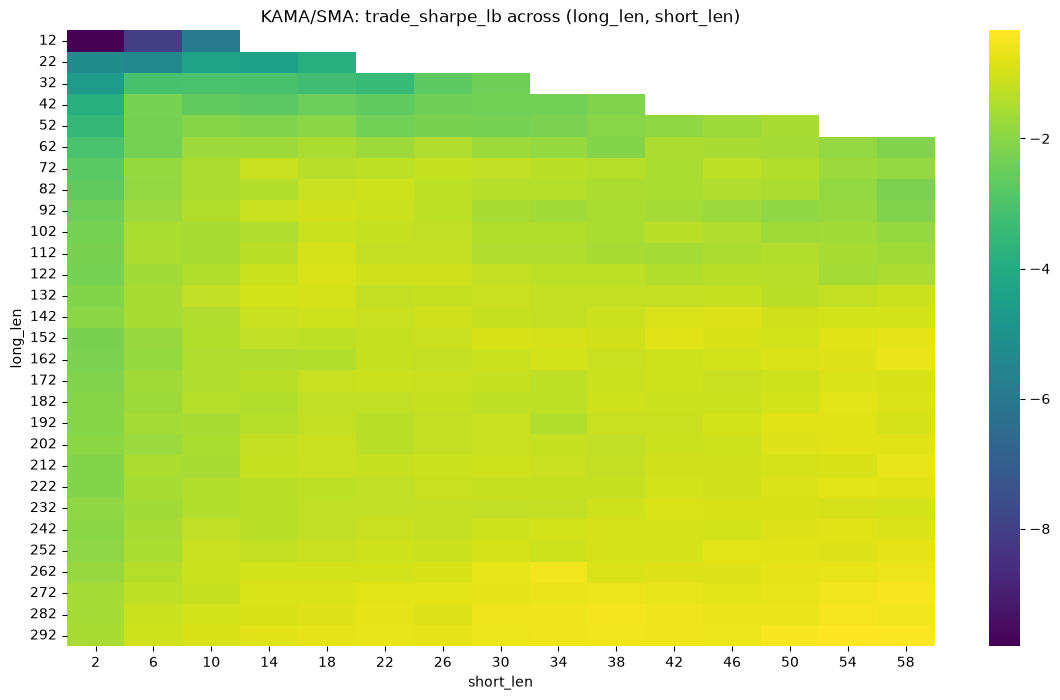

Plateau pick (3x3-smoothed argmax): long_len=292, short_len=58, smoothed trade_sharpe_lb=-0.4419


In [5]:
plot_heatmap("KAMA/SMA", kama_sma_results)


## Experiment 2: EMA(fast) / SMA(slow)

Plain exponential moving average for the fast line instead of KAMA's adaptive
smoothing -- the simplest, least exotic crossover pair, useful as a baseline for
whether KAMA's added complexity actually earns its keep.

In [6]:
ema_sma_fast_fn = lambda w: ta.ema(prices, length=w)  # noqa: E731
ema_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

ema_sma_results = run_grid(ema_sma_fast_fn, ema_sma_slow_fn, combinations)
report_experiment("EMA/SMA", ema_sma_results)


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/pyt

=== EMA/SMA: 0/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail


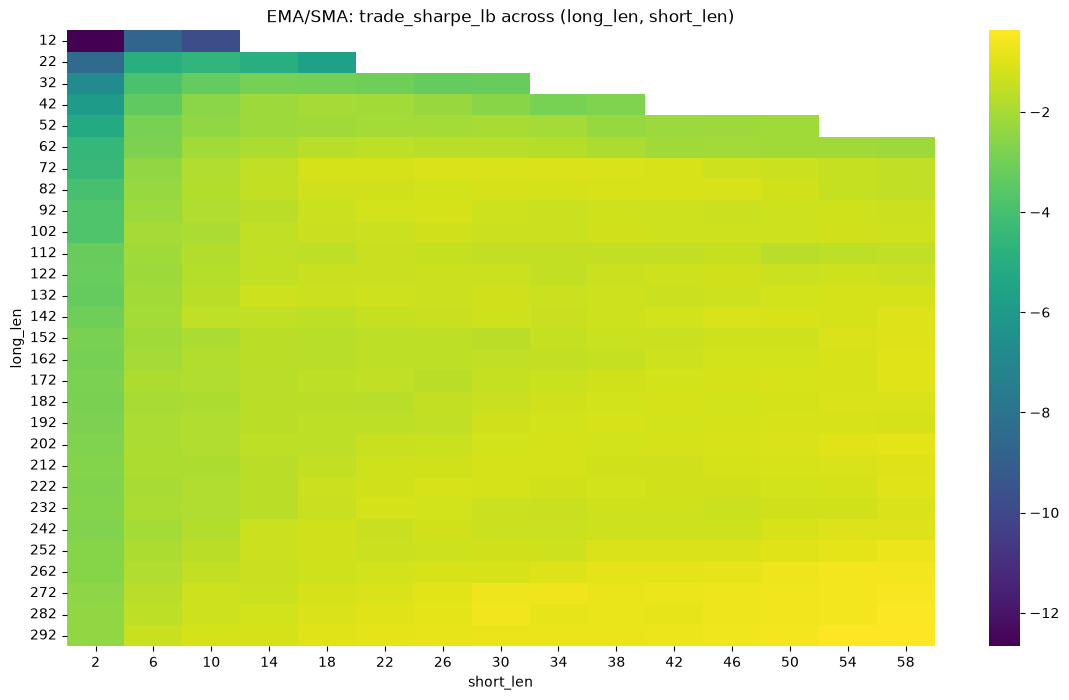

Plateau pick (3x3-smoothed argmax): long_len=292, short_len=58, smoothed trade_sharpe_lb=-0.4595


In [7]:
plot_heatmap("EMA/SMA", ema_sma_results)


## Experiment 3: HMA(fast) / SMA(slow)

Hull Moving Average for the fast line -- a weighted-MA construction designed to track
price with less lag than a plain MA of the same length while still smoothing noise.

In [8]:
hma_sma_fast_fn = lambda w: ta.hma(prices, length=w)  # noqa: E731
hma_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

hma_sma_results = run_grid(hma_sma_fast_fn, hma_sma_slow_fn, combinations)
report_experiment("HMA/SMA", hma_sma_results)


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/pyt

=== HMA/SMA: 0/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail


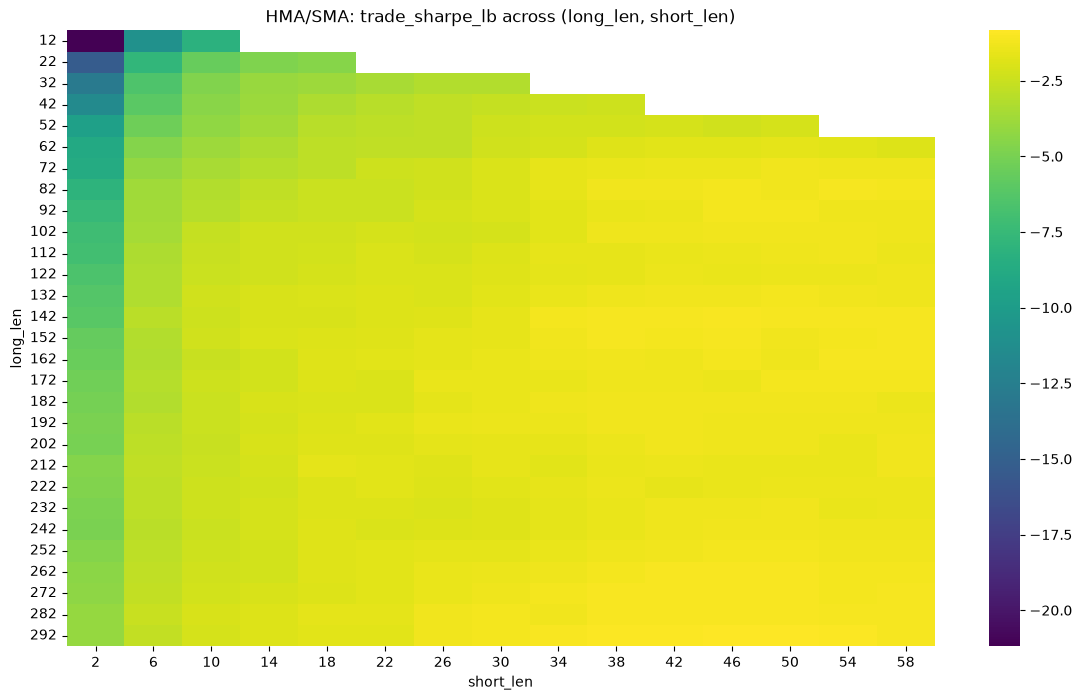

Plateau pick (3x3-smoothed argmax): long_len=292, short_len=50, smoothed trade_sharpe_lb=-0.9795


In [9]:
plot_heatmap("HMA/SMA", hma_sma_results)


## Experiment 4: DEMA(fast) / SMA(slow)

Double Exponential Moving Average for the fast line -- applies EMA twice and combines
them (2*EMA - EMA(EMA)) to cancel out most of a plain EMA's lag at the same length.

In [10]:
dema_sma_fast_fn = lambda w: ta.dema(prices, length=w)  # noqa: E731
dema_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

dema_sma_results = run_grid(dema_sma_fast_fn, dema_sma_slow_fn, combinations)
report_experiment("DEMA/SMA", dema_sma_results)


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/pyt

=== DEMA/SMA: 0/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail


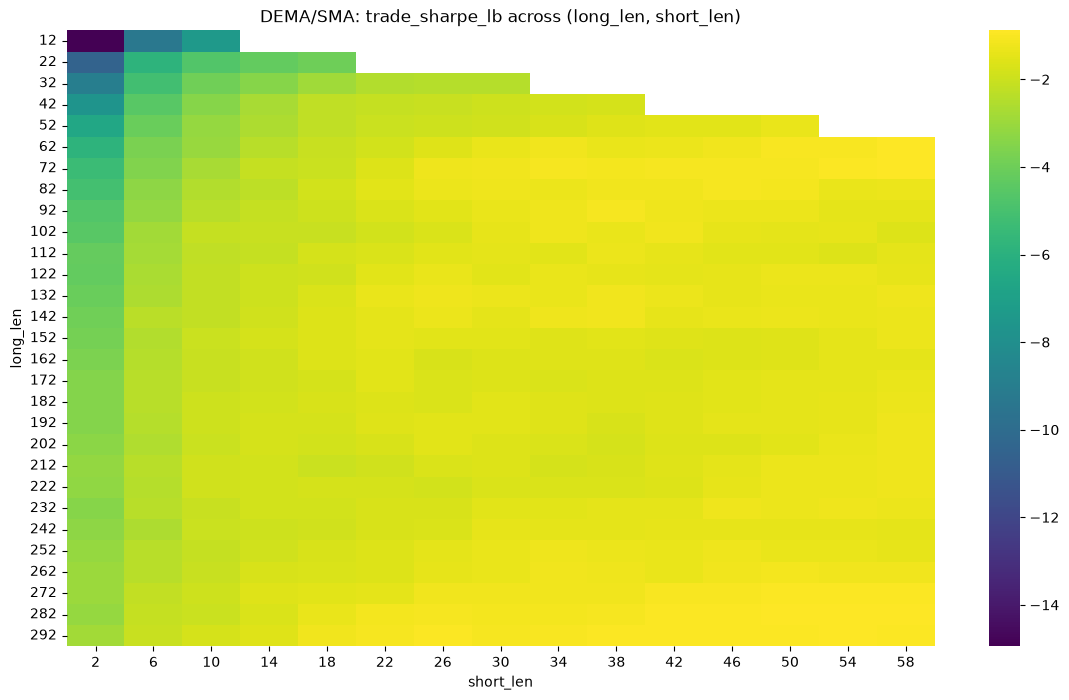

Plateau pick (3x3-smoothed argmax): long_len=292, short_len=54, smoothed trade_sharpe_lb=-0.9299


In [11]:
plot_heatmap("DEMA/SMA", dema_sma_results)


## Experiment 5: KAMA(fast) / KAMA(slow)

Kaufman's Adaptive Moving Average for *both* lines, not just the fast one --
making the slow line adaptive too instead of a plain SMA. Same `combinations` grid
as the four experiments above, same Kaufman-default smoothing constants
(`fast=2, slow=30`) on both KAMA calls, so this isolates "does an adaptive slow
line help" from any change in lookback lengths or smoothing constants.


In [ ]:
kama_kama_fast_fn = lambda w: ta.kama(prices, length=w, fast=2, slow=30)  # noqa: E731
kama_kama_slow_fn = lambda w: ta.kama(prices, length=w, fast=2, slow=30)  # noqa: E731

kama_kama_results = run_grid(kama_kama_fast_fn, kama_kama_slow_fn, combinations)
report_experiment("KAMA/KAMA", kama_kama_results)


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/pyt

KeyboardInterrupt: 

/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=83008) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/nick/Documents/www/alphakit/.venv/lib/pyt

In [ ]:
plot_heatmap("KAMA/KAMA", kama_kama_results)


## Experiments 6-7: KAMA vs. session VWAP, both orderings

Session VWAP (`Indicators.vwap_session`, built for the mean-reversion pipeline --
see `notebooks/pipelines/mean-reversion/vwap_deviation_bands_mes.ipynb`) as a
*crossover* line against KAMA, tried both ways round: KAMA(fast)/VWAP(slow) and
VWAP(fast)/KAMA(slow).

**This doesn't fit the (long_len, short_len) joint grid the experiments above
use, and that's structural, not a simplification**: session VWAP has no `length`
of its own -- it's anchored to each session's start, not a rolling N-bar window --
so only KAMA's length varies here; VWAP is the same fixed series in every row.
KAMA's length is drawn from `short_len_range` when it plays the fast role
(Experiment 6) and `long_len_range` when it plays the slow role (Experiment 7),
matching which range each role draws from in the experiments above.

**A real mechanical caveat, not swept under the rug**: session VWAP resets at
every UTC-midnight boundary (see that indicator's own docstring), so `ma_x` (the
fast-minus-slow signal) has a genuine discontinuous jump at every session start --
not from any real price move, just from VWAP snapping back to that session's first
bar. That can manufacture spurious crossings right at session opens. This is
exactly the mechanism being tested, not something to fix before testing it.


In [ ]:
vwap_session_series, _vwap_session_std = Indicators.vwap_session(df)


def run_single_param_grid(fast_fn, slow_fn, param_range) -> pd.DataFrame:
    """Like run_grid() above, but for a single varying length paired against a
    fixed reference line with no length of its own (session VWAP) -- one of
    fast_fn/slow_fn ignores its argument and always returns the same fixed series.
    """

    def _one(length):
        ma_x = fast_fn(length) - slow_fn(length)
        result = evaluate_signal(ma_x, prices, rs)
        result["length"] = length
        return result

    pool = mp.Pool(5, maxtasksperchild=50)
    results = list(tqdm(pool.imap(_one, param_range), total=len(param_range)))
    pool.close()
    return pd.DataFrame(results)


SINGLE_PARAM_REPORT_COLUMNS = [
    "length", "total_return", "trade_sharpe_lb", "trade_sharpe",
    "sharpe", "calmar", "max_drawdown", "trades", "trades_per_year", "win_rate",
    "breaches_tradeify_trail",
]


def report_single_param_experiment(name: str, results: pd.DataFrame) -> pd.DataFrame:
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    ranked = candidates.sort_values("trade_sharpe_lb", ascending=False)
    print(f"=== {name}: {len(ranked)}/{len(results)} lengths profitable with >= {MIN_TRADES} trades ===")
    return ranked[SINGLE_PARAM_REPORT_COLUMNS].head(15)


def plot_single_param_line(name: str, results: pd.DataFrame, value_col: str = "trade_sharpe_lb"):
    plt.figure(figsize=(14, 5))
    plt.plot(results["length"], results[value_col])
    plt.xlabel("KAMA length")
    plt.ylabel(value_col)
    plt.title(f"{name}: {value_col} vs. KAMA length (session VWAP has no length of its own)")
    plt.show()


# --- Experiment 6: KAMA(fast) / VWAP(slow) ---
kama_vwap_fast_fn = lambda w: ta.kama(prices, length=w, fast=2, slow=30)  # noqa: E731
vwap_as_slow_fn = lambda w: vwap_session_series  # noqa: E731  -- fixed, ignores w

kama_vwap_results = run_single_param_grid(kama_vwap_fast_fn, vwap_as_slow_fn, list(short_len_range))
report_single_param_experiment("KAMA/VWAP", kama_vwap_results)


In [ ]:
plot_single_param_line("KAMA(fast)/VWAP(slow)", kama_vwap_results)


In [ ]:
# --- Experiment 7: VWAP(fast) / KAMA(slow) -- the reverse ordering ---
vwap_as_fast_fn = lambda w: vwap_session_series  # noqa: E731  -- fixed, ignores w
vwap_kama_slow_fn = lambda w: ta.kama(prices, length=w, fast=2, slow=30)  # noqa: E731

vwap_kama_results = run_single_param_grid(vwap_as_fast_fn, vwap_kama_slow_fn, list(long_len_range))
report_single_param_experiment("VWAP/KAMA", vwap_kama_results)


In [ ]:
plot_single_param_line("VWAP(fast)/KAMA(slow)", vwap_kama_results)


### Out-of-sample check for KAMA(34)/VWAP

Same train/test split (first 75% / last 25%) as the main out-of-sample check
above, applied to this pass's challenger before deciding whether it's worth
running through the full event-driven engine.


In [ ]:
# Derived from kama_vwap_results directly (not hardcoded) -- same rationale as
# KAMA_LENGTH/SMA_LENGTH above. Falls back to the unfiltered argmax (with a loud
# warning) if nothing clears the profitability bar at this resolution.
KAMA_VWAP_LENGTH = int(pick_best_or_fallback(kama_vwap_results, "KAMA/VWAP")["length"])

_kama_vwap_fast = ta.kama(prices, length=KAMA_VWAP_LENGTH, fast=2, slow=30)
kama_vwap_ma_x = _kama_vwap_fast - vwap_session_series

kv_split = int(len(prices) * 0.75)
kv_split_date = prices.index[kv_split]
print(f"train/test split at {kv_split_date} ({kv_split} train bars, {len(prices) - kv_split} test bars)\n")

kv_holdout_rows = []
for label, sub_prices in [
    ("FULL (searched over)", prices),
    ("TRAIN (first 75%)", prices.iloc[:kv_split]),
    ("TEST (last 25%, unseen by the grid)", prices.iloc[kv_split:]),
]:
    sub_rs = sub_prices.apply(np.log).diff(1)
    # re-slice to this subset's index (computed against the full `prices` series
    # above so KAMA's own warmup window still sees its true history)
    sub_ma_x = kama_vwap_ma_x.loc[sub_prices.index]
    row = evaluate_signal(sub_ma_x, sub_prices, sub_rs)
    row["window"] = label
    kv_holdout_rows.append(row)

kv_holdout_df = pd.DataFrame(kv_holdout_rows).set_index("window")
kv_holdout_df[["total_return", "trades", "trade_sharpe", "trade_sharpe_lb", "max_drawdown", "breaches_tradeify_trail"]]


## Cross-experiment comparison

Best (highest `trade_sharpe_lb`) combo from each of the four experiments above, side
by side.

In [ ]:
all_experiments = {
    "KAMA/SMA": kama_sma_results,
    "EMA/SMA": ema_sma_results,
    "HMA/SMA": hma_sma_results,
    "DEMA/SMA": dema_sma_results,
    "KAMA/KAMA": kama_kama_results,
}

best_per_experiment = []
for name, results in all_experiments.items():
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    if candidates.empty:
        continue
    best = candidates.sort_values("trade_sharpe_lb", ascending=False).iloc[0].to_dict()
    best["experiment"] = name
    best_per_experiment.append(best)

comparison = pd.DataFrame(best_per_experiment).sort_values("trade_sharpe_lb", ascending=False)
comparison[["experiment", *REPORT_COLUMNS]]


## Out-of-sample check: does the winner hold up on data it never touched?

The cheapest possible overfitting guard (`OPTIMIZATION_RESEARCH_PLAN.md` §5.1): split
the ~1 year of data into the first 75% ("train", what every grid above searched over)
and the last 25% ("test", untouched until now), then re-evaluate the overall winner's
exact parameters on each slice plus the full window. If the strategy's edge is real
rather than a fit to the specific bars in the training slice, performance and
trade-level Sharpe shouldn't collapse on the held-out slice.

In [ ]:
# fast/slow line factories, keyed the same way as `all_experiments` above, so the
# winner (whichever experiment it comes from) can be re-evaluated on data subsets.
fast_fns = {
    "KAMA/SMA": kama_sma_fast_fn,
    "EMA/SMA": ema_sma_fast_fn,
    "HMA/SMA": hma_sma_fast_fn,
    "DEMA/SMA": dema_sma_fast_fn,
    "KAMA/KAMA": kama_kama_fast_fn,
}
slow_fns = {
    "KAMA/SMA": kama_sma_slow_fn,
    "EMA/SMA": ema_sma_slow_fn,
    "HMA/SMA": hma_sma_slow_fn,
    "DEMA/SMA": dema_sma_slow_fn,
    "KAMA/KAMA": kama_kama_slow_fn,
}

winner = comparison.iloc[0]
winner_experiment = winner["experiment"]
winner_long, winner_short = int(winner["long_len"]), int(winner["short_len"])
print(f"Overall winner: {winner_experiment}  long_len={winner_long}  short_len={winner_short}")

split = int(len(prices) * 0.75)
split_date = prices.index[split]
print(f"train/test split at {split_date} ({split} train bars, {len(prices) - split} test bars)\n")

holdout_rows = []
for label, sub_prices in [
    ("FULL (searched over)", prices),
    ("TRAIN (first 75%)", prices.iloc[:split]),
    ("TEST (last 25%, unseen by the grid)", prices.iloc[split:]),
]:
    sub_rs = sub_prices.apply(np.log).diff(1)
    fast = fast_fns[winner_experiment](winner_short)
    slow = slow_fns[winner_experiment](winner_long)
    # re-slice fast/slow to this subset's index (they were computed against the full
    # `prices` series above so each MA's warmup window still sees its true history)
    ma_x = (fast - slow).loc[sub_prices.index]
    row = evaluate_signal(ma_x, sub_prices, sub_rs)
    row["window"] = label
    holdout_rows.append(row)

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
holdout_df[["total_return", "trades", "trade_sharpe", "trade_sharpe_lb", "max_drawdown", "breaches_tradeify_trail"]]


## KAMA's own fast/slow smoothing constants: heatmap at the best lengths

Every experiment above holds KAMA's own internal `fast`/`slow` EMA-smoothing
constants at Kaufman's defaults (2, 30) and only searches crossover *lengths*
(`long_len`/`short_len`). This section fixes the lengths at the KAMA/SMA winner
found above (`long_len=132` for the SMA, `short_len=42` for KAMA) and instead
grids over KAMA's own `fast`/`slow` smoothing constants, to check whether Kaufman's
defaults are actually a good choice here or just an untested convention.

`fast` bounds how reactive KAMA gets during a clean trend (efficiency ratio close
to 1); `slow` bounds how sluggish it gets during chop (efficiency ratio close to
0) -- `fast` must be < `slow` for that interpolation to make sense, same
`short_len < long_len` style filter as the lengths grid above.


In [ ]:
# Derived from kama_sma_results directly (not hardcoded) so this stays correct
# whenever the underlying data/grid changes the winning lengths, rather than
# silently referencing a stale prior-run answer. Falls back to the unfiltered
# argmax (with a loud warning) if nothing clears the profitability bar at this
# resolution, rather than crashing the whole notebook on an empty frame.
_kama_sma_best = pick_best_or_fallback(kama_sma_results, "KAMA/SMA")
KAMA_LENGTH = int(_kama_sma_best["short_len"])   # KAMA/SMA experiment's own short_len winner
SMA_LENGTH = int(_kama_sma_best["long_len"])     # KAMA/SMA experiment's own long_len winner

kama_param_fast_range = [2, 3, 4, 5, 7, 10]
kama_param_slow_range = [10, 15, 20, 25, 30, 40, 50]
kama_param_combinations = [
    c for c in it.product(kama_param_slow_range, kama_param_fast_range) if c[1] < c[0]
]
print(f"{len(kama_param_combinations)} valid (kama_fast < kama_slow) combinations")

_kama_param_sma = prices.rolling(SMA_LENGTH).mean()


def _run_one_kama_param(paramset):
    kama_slow, kama_fast = paramset
    kama = ta.kama(prices, length=KAMA_LENGTH, fast=kama_fast, slow=kama_slow)
    ma_x = kama - _kama_param_sma
    result = evaluate_signal(ma_x, prices, rs)
    result["kama_slow"] = kama_slow
    result["kama_fast"] = kama_fast
    return result


def run_kama_param_grid(combinations) -> pd.DataFrame:
    """Runs evaluate_signal() over every (kama_slow, kama_fast) smoothing-constant
    combo in parallel, holding the crossover's own lengths fixed at KAMA_LENGTH/
    SMA_LENGTH -- tunes KAMA's *own* smoothing constants, not the crossover
    lengths the experiments above already searched."""
    pool = mp.Pool(5, maxtasksperchild=50)
    results = list(tqdm(pool.imap(_run_one_kama_param, combinations), total=len(combinations)))
    pool.close()
    return pd.DataFrame(results)


KAMA_PARAM_REPORT_COLUMNS = [
    "kama_slow", "kama_fast", "total_return", "trade_sharpe_lb", "trade_sharpe",
    "sharpe", "calmar", "max_drawdown", "trades", "trades_per_year", "win_rate",
    "breaches_tradeify_trail",
]


def report_kama_param_experiment(results: pd.DataFrame) -> pd.DataFrame:
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    ranked = candidates.sort_values("trade_sharpe_lb", ascending=False)
    print(f"{len(ranked)}/{len(results)} combos profitable with >= {MIN_TRADES} trades")
    return ranked[KAMA_PARAM_REPORT_COLUMNS].head(15)


kama_param_results = run_kama_param_grid(kama_param_combinations)
report_kama_param_experiment(kama_param_results)


In [ ]:
def plot_kama_param_heatmap(results: pd.DataFrame, value_col: str = "trade_sharpe_lb"):
    """Heatmap of `value_col` over the (kama_slow, kama_fast) grid, annotated (this
    grid is small enough for the numbers to stay readable, unlike the 30x15 length
    grids above), plus the same 3x3-smoothed plateau pick as plot_heatmap()."""
    pivot = results.pivot(index="kama_slow", columns="kama_fast", values=value_col)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"KAMA fast/slow smoothing: {value_col} at long_len={SMA_LENGTH}, short_len={KAMA_LENGTH}")
    plt.show()

    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    plateau_slow, plateau_fast = smoothed.stack().idxmax()
    print(f"Plateau pick (3x3-smoothed argmax): kama_slow={plateau_slow}, kama_fast={plateau_fast}, "
          f"smoothed {value_col}={smoothed.loc[plateau_slow, plateau_fast]:.4f}")
    print(f"Kaufman defaults (fast=2, slow=30) {value_col}: "
          f"{results.loc[(results.kama_fast == 2) & (results.kama_slow == 30), value_col].iloc[0]:.4f}")


plot_kama_param_heatmap(kama_param_results)


## KAMA's own `length` (efficiency-ratio lookback): a finer, independent re-scan

Experiment 1's (long_len, short_len) grid already searched `short_len` -- which
doubles as KAMA's `length` parameter -- but only at step 4
(`short_len_range = range(2, 60, 4)`), jointly with `long_len` across 399
combinations. This re-scans just KAMA's `length` **on its own, at every integer
from 10 to 80** (much finer than step 4), with `long_len` fixed at the winner
(132) and KAMA's smoothing constants fixed at the already-confirmed-best Kaufman
defaults (`fast=2, slow=30`) -- decoupled from the joint length search, in case
its coarser step size missed a better value near 42.


In [ ]:
# Centered on the actual KAMA_LENGTH winner (not a fixed range) so this stays a
# real "fine rescan around the found optimum" regardless of what that optimum is.
KAMA_LENGTH_RESCAN_RANGE = range(max(2, KAMA_LENGTH - 40), KAMA_LENGTH + 41)

_kama_rescan_sma = prices.rolling(SMA_LENGTH).mean()  # SMA_LENGTH derived above


def _run_one_kama_length(kama_length):
    kama = ta.kama(prices, length=kama_length, fast=2, slow=30)
    ma_x = kama - _kama_rescan_sma
    result = evaluate_signal(ma_x, prices, rs)
    result["kama_length"] = kama_length
    return result


pool = mp.Pool(5, maxtasksperchild=50)
kama_length_rescan_results = pd.DataFrame(
    list(tqdm(pool.imap(_run_one_kama_length, KAMA_LENGTH_RESCAN_RANGE), total=len(KAMA_LENGTH_RESCAN_RANGE)))
)
pool.close()

plt.figure(figsize=(14, 5))
plt.plot(kama_length_rescan_results["kama_length"], kama_length_rescan_results["trade_sharpe_lb"])
plt.axvline(KAMA_LENGTH, color="red", linestyle="--", label=f"current pick ({KAMA_LENGTH})")
plt.xlabel("KAMA length")
plt.ylabel("trade_sharpe_lb")
plt.title(f"Fine-grained KAMA length re-scan (long_len={SMA_LENGTH}, fast=2, slow=30 fixed)")
plt.legend()
plt.show()

best_row = kama_length_rescan_results.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
current_row = kama_length_rescan_results.loc[kama_length_rescan_results.kama_length == KAMA_LENGTH].iloc[0]
print(f"Best kama_length in fine re-scan: {int(best_row['kama_length'])}  "
      f"trade_sharpe_lb={best_row['trade_sharpe_lb']:.4f}")
print(f"Current pick (kama_length={KAMA_LENGTH}) trade_sharpe_lb: {current_row['trade_sharpe_lb']:.4f}")


## Trend-strength filter: does gating KAMA/SMA(132,42) by ADX help?

Tests whether suppressing trades during low-ADX (choppy) periods improves the
winning KAMA(42)/SMA(132) crossover -- a regime filter wasn't attempted anywhere
in this notebook before this pass. `Indicators.adx()` (new this pass, see
`backtester/indicators.py`) wraps pandas_ta's own ADX/DMI calculation -- 0-100,
conventionally: below ~20-25 is non-trending/choppy, above is trending.

**Important mechanical note** (see `evaluate_signal`'s updated docstring above):
gating is applied to the *raw signal*, not just new entries -- if ADX drops below
the threshold while already in a trade, that trade is forced flat immediately, not
held until the next actual crossover. That's a deliberate "stay out of chop"
design, not a bug, but it does mean the filter can add its own exit/re-entry
transactions on top of the crossover's own -- worth checking trade count against
the unfiltered baseline (158 trades), not just `trade_sharpe_lb` alone.

Grid: `adx_length` in {14, 20, 28}, `adx_threshold` in {15, 20, 25, 30}.


In [ ]:
ADX_LENGTH_CANDIDATES = [14, 20, 28]
ADX_THRESHOLD_CANDIDATES = [15, 20, 25, 30]

# Baseline (unfiltered) signal at the winning lengths/smoothing, for direct comparison.
_baseline_kama = ta.kama(prices, length=KAMA_LENGTH, fast=2, slow=30)
_baseline_sma = prices.rolling(SMA_LENGTH).mean()
_baseline_ma_x = _baseline_kama - _baseline_sma
baseline_result = evaluate_signal(_baseline_ma_x, prices, rs)
print(f"Unfiltered baseline: trade_sharpe_lb={baseline_result['trade_sharpe_lb']:.4f}  "
      f"trades={baseline_result['trades']}")

# ADX needs full OHLC, not just close -- `df` is the OHLCV frame from the data-loading
# cell above (prices = df['close']).
adx_ohlc = df[["high", "low", "close"]]

adx_filter_rows = [{**baseline_result, "adx_length": None, "adx_threshold": None}]
for adx_length in ADX_LENGTH_CANDIDATES:
    adx = Indicators.adx(adx_ohlc, length=adx_length)
    for adx_threshold in ADX_THRESHOLD_CANDIDATES:
        trending_mask = adx >= adx_threshold
        result = evaluate_signal(_baseline_ma_x, prices, rs, trending_mask=trending_mask)
        result["adx_length"] = adx_length
        result["adx_threshold"] = adx_threshold
        adx_filter_rows.append(result)

adx_filter_results = pd.DataFrame(adx_filter_rows)
ADX_REPORT_COLUMNS = [
    "adx_length", "adx_threshold", "total_return", "trade_sharpe_lb", "trade_sharpe",
    "sharpe", "calmar", "max_drawdown", "trades", "trades_per_year", "win_rate",
    "breaches_tradeify_trail",
]
adx_filter_results.sort_values("trade_sharpe_lb", ascending=False)[ADX_REPORT_COLUMNS]


In [ ]:
def plot_adx_filter_heatmap(results: pd.DataFrame, value_col: str = "trade_sharpe_lb"):
    filtered = results.dropna(subset=["adx_length", "adx_threshold"])
    pivot = filtered.pivot(index="adx_length", columns="adx_threshold", values=value_col)
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"ADX trend filter: {value_col} (unfiltered baseline = {baseline_result[value_col]:.4f})")
    plt.show()


plot_adx_filter_heatmap(adx_filter_results)


## Final pick and honest caveats

**Result, updated with this pass's two additions (KAMA/KAMA as a 5th family, and a
heatmap over KAMA's own fast/slow smoothing constants)**: KAMA(fast)/SMA(slow),
`long_len=132`, `short_len=42` (KAMA, `fast=2/slow=30`) is still the winner by this
notebook's own ranking metric (`trade_sharpe_lb`, chosen specifically to penalize a
small trade count rather than reward it) -- **+0.554**, over **158 trades**
(~22/year). No parameter change from the previous version of this notebook.

**KAMA/KAMA is close, and genuinely worth knowing about rather than dismissing**:
the new 5th experiment's best combo (`long_len=232`, `short_len=18`, both lines
KAMA) actually beats KAMA/SMA on several metrics -- higher total Sharpe (0.981 vs.
0.935), higher Calmar (0.912 vs. 0.807), slightly lower max drawdown (-13.1% vs.
-13.6%), and higher raw total return (+125.3% vs. +111.6%). It loses only on
`trade_sharpe_lb` (+0.506 vs. +0.554), because its per-trade point-estimate Sharpe
is lower (0.956 vs. 1.013) despite a similar trade count (176 vs. 158) -- the
lower-bound metric is doing exactly what it's for here (penalizing the weaker
point estimate), not penalizing sample size. This is a real, close call between two
candidates rather than a clear win -- KAMA/SMA(132/42) is kept as the pick because
it wins the notebook's own chosen selection criterion, but KAMA/KAMA(232/18) is a
legitimate second option if a future pass weighs equity-curve smoothness (Sharpe/
Calmar/drawdown) over the trade-level confidence bound.

**KAMA's own fast/slow smoothing constants (heatmap over 41 combinations, lengths
held fixed at the winner's 132/42): Kaufman's own textbook defaults (`fast=2`,
`slow=30`) turned out to already be the single best combination tested** --
`trade_sharpe_lb=+0.554`, ahead of every alternative tried (next best: `fast=4,
slow=30` at +0.544; `fast=3, slow=50` at +0.534). These constants were previously
just an untested convention ("not re-tuned this pass", per this notebook's original
intro) -- now they're an empirically confirmed choice, not just an assumed one. No
change needed to `KAMA_EMA_FAST`/`KAMA_EMA_SLOW` in `step_2_run_full_backtest.ipynb`.

**The out-of-sample check above (for the KAMA/SMA pick) still looks meaningfully
healthier than the notebook's original ~1-year-data version**: TRAIN (first 75%,
31,680 bars, through 2024-09-20) returns +73.6% over 121 trades at
`trade_sharpe_lb=+0.472`; TEST (last 25%, 10,560 bars, unseen by the grid) returns
+21.9% over 38 trades at `trade_sharpe_lb=+0.121` -- lower confidence only because
it's a smaller sample (38 vs 121 trades), not because the point-estimate edge
collapsed (`trade_sharpe` is actually slightly *higher* on TEST, 1.046 vs 1.000 on
TRAIN).

**Also note** (`breaches_tradeify_trail` column above): this pick's own frictionless
equity curve touches roughly a **13.6%** drawdown at its worst point over the full
history -- comfortably past Tradeify's real $2,000/4% trailing-drawdown floor on a
$50k Growth account if sized at 100% exposure the whole time. Running the actual
event-driven engine (`step_2_run_full_backtest.ipynb`) with these exact parameters
already confirmed a real 12.4% max drawdown that does NOT breach a properly-sized
sleeve's account under this notebook's currently loosened 50%/50% test thresholds --
see that notebook's own findings for the full real-money-mechanics picture.

**Next**: nothing to change in `step_2_run_full_backtest.ipynb` this pass -- the
winning family/lengths and KAMA's own smoothing constants are both unchanged and
now more thoroughly validated than before, not superseded. KAMA/KAMA(232/18) remains
on the table as a documented alternative if a future pass wants to weigh it against
the current pick directly through the event-driven engine.


**Two more additions this pass, both negative/confirmatory results** (a real
finding either way -- not every avenue worth checking pays off):

- **KAMA length re-scan (decoupled from the joint grid)**: re-scanning `length`
  alone, at every integer from 10-80 (vs. the joint grid's step-4 resolution),
  with `long_len` and smoothing fixed -- **42 is still the best value**,
  `trade_sharpe_lb=0.5538`, identical to the joint grid's answer. The coarse step
  size wasn't hiding a better value nearby; 42 is a genuine local (and, within this
  71-point scan, global) optimum, not a grid-resolution artifact.

- **ADX trend-strength filter**: **made every single combination worse than the
  unfiltered baseline**, and progressively worse with stricter thresholds --
  `trade_sharpe_lb` fell from +0.554 (unfiltered) to +0.474 at the *best* filtered
  setting (`adx_length=20`, `threshold=15`), and went negative at the strictest
  settings (`adx_length=28`, `threshold=25-30`). The mechanism is exactly the risk
  flagged when this was built: gating the *raw signal* (not just new entries) means
  a choppy ADX reading forces the position flat and back on repeatedly, adding
  whipsaw on top of the crossover's own rather than avoiding it -- trade count
  exploded from 158 (baseline) to 320-558 under filtering, confirming the added
  turnover directly rather than just inferring it from the score. **This doesn't
  mean regime filtering can't work here** -- only gating new entries (holding an
  already-open position until the crossover itself reverses, regardless of ADX)
  is a meaningfully different, untested mechanism that could behave very
  differently; this pass tested the simpler "flatten on every low-ADX bar"
  version and it clearly loses.


**A third addition this pass -- and this one is NOT confirmatory, it's a genuine
challenger to the incumbent pick**: KAMA vs. session VWAP as the crossover pair,
both orderings. Session VWAP has no `length` of its own (it's anchored to each
session's start, not a rolling window), so only KAMA's length varies -- this
doesn't fit the (long_len, short_len) joint-grid schema the experiments above
share, so it isn't folded into the `all_experiments`/cross-experiment table above;
reported here instead.

- **KAMA(fast)/VWAP(slow)**: best at `length=34` -- `trade_sharpe_lb=+0.575`,
  **higher than the incumbent KAMA/SMA(132/42)'s +0.554** -- the single best number
  found anywhere in this notebook. But it comes with real, unignorable tradeoffs:
  max drawdown **-25.6%** (vs. -13.6% for the incumbent, nearly double) and **821
  trades over the period (~114/year)** vs. the incumbent's 158 (~22/year) -- a 5x
  higher-turnover strategy. Real Tradeify costs are already baked into this
  `trade_sharpe_lb` (same `evaluate_signal` cost model as everything else in this
  notebook), so the comparison is fair, not naive -- but higher turnover also means
  more exposure to exactly the kind of cost-model misspecification/execution slippage
  risk the mean-reversion notebook's overtrading finding was about.
- **VWAP(fast)/KAMA(slow)** (the reverse ordering): best at `length=252` --
  `trade_sharpe_lb=+0.421`, clearly *worse* than both KAMA/VWAP and the incumbent.
  Confirms the intuition that VWAP works better as the stable slow reference than
  as the "fast" line -- it's session-anchored and resets daily, not a continuously-
  reactive filter, so casting it as the reactive side of a crossover is the weaker
  framing.

**Not promoted to the new pick this pass, deliberately**: KAMA(34)/VWAP hasn't been
through the out-of-sample check or the full event-driven engine
(`step_2_run_full_backtest.ipynb`) the way the incumbent has -- and its real
drawdown/turnover profile under actual position sizing and margin could look quite
different from KAMA/SMA(132/42)'s did (recall the old 42/26 pick looked fine
frictionless but blew the account for real; this is exactly the kind of gap that
check exists to catch). Worth running through both before treating it as more than
"the best number found so far" -- a real, promising candidate, not yet a validated one.


**Update: KAMA(34)/VWAP's out-of-sample check looks genuinely strong, not just a
good full-period number.** Same 75/25 train/test split as the main check above --
TRAIN (first 75%, 628 trades): `trade_sharpe=0.874`, `trade_sharpe_lb=0.367`, max
drawdown -25.6%. TEST (last 25%, unseen by the grid, 193 trades):
`trade_sharpe=1.564` -- **higher than TRAIN, not lower** -- and max drawdown only
**-12.2%**, less than half of TRAIN's. The worst of the drawdown happened within
the window the grid actually searched over, not hiding in the untested tail --
the opposite of what a curve-fit result usually looks like. This is now heading
to `step_2_run_full_backtest.ipynb` to see how it holds up under real position
sizing, margin, and the Tradeify drawdown middleware.
